# NovelForge - Jalon 2 : EDA

Objectif : analyser la qualité du dataset de Light Novels / Manhwas avant la modélisation multi-label des genres à partir des synopsis.

Cette EDA couvre les exigences du jalon : nettoyage robuste, statistiques descriptives, détection d'anomalies et visualisations soignées.

## 1. Initialisation

Les traitements lourds sont importés depuis `src/preprocessing.py` et `src/visualization.py` afin de garder le notebook lisible et modulaire.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preprocessing import (
    TextPreprocessor,
    add_filtered_label_column,
    clean_dataframe,
    detect_synopsis_anomalies,
    drop_columns_if_present,
    infer_column,
    remove_synopsis_anomalies,
)
from visualization import (
    count_genres,
    plot_missing_values,
    plot_synopsis_length_distribution,
    plot_top_genres,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 50)

PROJECT_DIR

WindowsPath('C:/Users/ClémentPERRET/OneDrive - EQUATERRE-VDS/Bureau/Cours/DeepLearning')

## 2. Chargement du dataset

Le notebook charge le fichier `data/data.csv` du dataset Manga/Manhwa/Manhua. Un tableau `colonnes_a_supprimer` permet d'enlever les colonnes techniques non utiles a l'analyse, comme l'URL de couverture.

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".json", ".jsonl"}:
        return pd.read_json(path, lines=suffix == ".jsonl")
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported dataset format: {suffix}")


env_path = os.getenv("NOVELFORGE_DATASET")
candidate_paths = []
if env_path:
    candidate_paths.append(Path(env_path))

candidate_names = [
    "data.csv",
    "dataset.csv",
    "novelforge.csv",
    "manga_manhwa_manhua.csv",
    "manga.csv",
]
for folder in [PROJECT_DIR / "data", PROJECT_DIR.parent / "data", PROJECT_DIR]:
    candidate_paths.extend(folder / name for name in candidate_names)

dataset_path = next((path for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    searched = "\n".join(str(path) for path in candidate_paths)
    raise FileNotFoundError(
        "Dataset not found. Place it in data/ or set NOVELFORGE_DATASET.\n"
        f"Searched paths:\n{searched}"
    )

df_raw = load_dataset(dataset_path)

colonnes_a_supprimer = ["cover"]
df_raw = drop_columns_if_present(df_raw, colonnes_a_supprimer)

print(f"Dataset loaded: {dataset_path}")
print(f"Columns removed if present: {colonnes_a_supprimer}")
print(f"Shape after structural cleaning: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
display(df_raw.head())

Dataset loaded: C:\Users\ClémentPERRET\OneDrive - EQUATERRE-VDS\Bureau\Cours\DeepLearning\data\data.csv
Columns removed if present: ['cover']
Shape after structural cleaning: 70,948 rows x 5 columns


,title,description,rating,year,tags
0,Salad Days (Tang LiuZang) - Part 2,The second season of Salad Days (Tang LiuZang).,4.7,2021.0,"['BL', 'Manhua', 'Romance', 'Shounen-ai', 'Sports', 'Webtoons', 'Full Color']"
1,The Master of Diabolism,"As the grandmaster who founded the Demonic Sect, Wei WuXian roamed the world in his wanton ways, hated by millions for the chaos he crea...",4.7,2017.0,"['Action', 'Adventure', 'BL', 'Comedy', 'Manhua', 'Mystery', 'Romance', 'Shounen-ai', 'Ancient China', 'Cultivation', 'Martial Arts', 'S..."
2,JoJo's Bizarre Adventure Part 7: Steel Ball Run,"Set in 1890, Steel Ball Run spotlights Gyro Zepelli and Johnny Joestar as they pit their spirits on a Fifty Million Dollar race across t...",4.7,2004.0,"['Action', 'Adventure', 'Horror', 'Mystery', 'Seinen', '19th Century', 'America', 'Historical']"
3,A Sign of Affection,"Yuki is a typical college student, whose world revolves around her friends, social media, and the latest sales. But when a chance encoun...",4.7,2019.0,"['Romance', 'Shoujo', 'Slice of Life', 'Disability']"
4,Moriarty the Patriot,"Before he was Sherlock’s rival, Moriarty fought against the unfair class caste system in London by making sure corrupt nobility got thei...",4.7,2016.0,"['Mystery', 'Shounen', 'Detectives', 'England', 'Europe', 'Historical', 'Sherlock Holmes', 'Adapted to Anime', 'Based on a Novel']"


## 3. Identification des colonnes utiles

Le nouveau dataset contient une vraie colonne `description`, utilisee comme synopsis, et une colonne `tags`, filtree pour conserver une taxonomie de genres exploitable en multilabel.

In [3]:
TEXT_COLUMN = infer_column(
    df_raw.columns,
    candidates=["synopsis", "summary", "description", "overview", "plot", "resume"],
)
GENRE_COLUMN = infer_column(
    df_raw.columns,
    candidates=["genres", "genre", "tags", "categories", "labels", "target"],
)

GENRE_VOCABULARY = [
    "Action",
    "Adventure",
    "Comedy",
    "Drama",
    "Fantasy",
    "Romance",
    "School Life",
    "Slice of Life",
    "Supernatural",
    "Mystery",
    "Psychological",
    "Horror",
    "Historical",
    "Sci Fi",
    "Sports",
    "Martial Arts",
    "Magic",
    "Isekai",
    "Harem",
    "Mecha",
    "Demons",
    "Seinen",
    "Shoujo",
    "Shounen",
    "Josei",
    "BL",
    "GL",
    "Yaoi",
    "Yuri",
    "Shounen-ai",
    "Shoujo-ai",
    "Smut",
    "Wuxia",
    "Xianxia",
]

df_raw = add_filtered_label_column(
    df_raw,
    label_column=GENRE_COLUMN,
    output_column="genre_labels",
    allowed_labels=GENRE_VOCABULARY,
)

print(f"Text column: {TEXT_COLUMN}")
print(f"Raw label column: {GENRE_COLUMN}")
print(f"Filtered genre column: genre_labels")
print(f"Genre taxonomy size: {len(GENRE_VOCABULARY)}")
display(df_raw[[TEXT_COLUMN, GENRE_COLUMN, "genre_labels"]].head())

Text column: description
Raw label column: tags
Filtered genre column: genre_labels
Genre taxonomy size: 34


,description,tags,genre_labels
0,The second season of Salad Days (Tang LiuZang).,"['BL', 'Manhua', 'Romance', 'Shounen-ai', 'Sports', 'Webtoons', 'Full Color']","[BL, Romance, Shounen-ai, Sports]"
1,"As the grandmaster who founded the Demonic Sect, Wei WuXian roamed the world in his wanton ways, hated by millions for the chaos he crea...","['Action', 'Adventure', 'BL', 'Comedy', 'Manhua', 'Mystery', 'Romance', 'Shounen-ai', 'Ancient China', 'Cultivation', 'Martial Arts', 'S...","[Action, Adventure, BL, Comedy, Mystery, Romance, Shounen-ai, Martial Arts, Supernatural, Xianxia]"
2,"Set in 1890, Steel Ball Run spotlights Gyro Zepelli and Johnny Joestar as they pit their spirits on a Fifty Million Dollar race across t...","['Action', 'Adventure', 'Horror', 'Mystery', 'Seinen', '19th Century', 'America', 'Historical']","[Action, Adventure, Horror, Mystery, Seinen, Historical]"
3,"Yuki is a typical college student, whose world revolves around her friends, social media, and the latest sales. But when a chance encoun...","['Romance', 'Shoujo', 'Slice of Life', 'Disability']","[Romance, Shoujo, Slice of Life]"
4,"Before he was Sherlock’s rival, Moriarty fought against the unfair class caste system in London by making sure corrupt nobility got thei...","['Mystery', 'Shounen', 'Detectives', 'England', 'Europe', 'Historical', 'Sherlock Holmes', 'Adapted to Anime', 'Based on a Novel']","[Mystery, Shounen, Historical]"


## 4. Qualité des données et nettoyage robuste

Le nettoyage applique une normalisation contrôlée : valeurs nulles transformées en chaîne vide, suppression du HTML et des URL, passage en minuscules, normalisation des espaces et lemmatisation basique.

,missing_rate_%
rating,57.897333
year,1.161414
description,0.043694
title,0.000000
tags,0.000000
genre_labels,0.000000


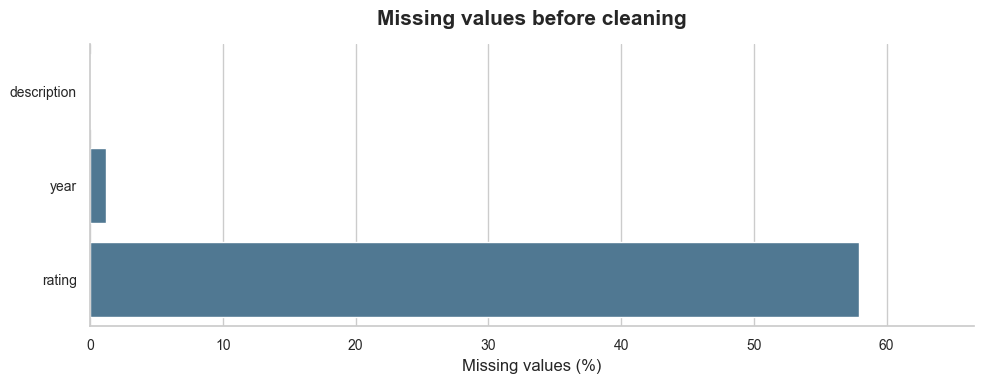

In [4]:
display(df_raw.isna().mean().mul(100).sort_values(ascending=False).to_frame("missing_rate_%").head(15))
plot_missing_values(df_raw, title="Missing values before cleaning");

**Lecture analytique.** Le graphique des valeurs manquantes permet d'identifier les colonnes fragiles avant toute modélisation. Une forte proportion de valeurs nulles sur le synopsis serait critique, car elle réduit directement le signal textuel disponible pour prédire les genres.

In [5]:
preprocessor = TextPreprocessor(lowercase=True, remove_urls=True, lemmatize=True)
df = clean_dataframe(
    df_raw,
    text_column=TEXT_COLUMN,
    clean_column="synopsis_clean",
    preprocessor=preprocessor,
)

display(df[[TEXT_COLUMN, "synopsis_clean", "word_count", "char_count"]].head())

,description,synopsis_clean,word_count,char_count
0,The second season of Salad Days (Tang LiuZang).,the second season of salad day tang liuzang,8,43
1,"As the grandmaster who founded the Demonic Sect, Wei WuXian roamed the world in his wanton ways, hated by millions for the chaos he crea...",as the grandmaster who found the demonic sect wei wuxian roam the world in his wanton way hat by million for the chao he creat in the en...,76,397
2,"Set in 1890, Steel Ball Run spotlights Gyro Zepelli and Johnny Joestar as they pit their spirits on a Fifty Million Dollar race across t...",set in steel ball run spotlight gyro zepelli and johnny joestar as they pit their spirit on a fifty million dollar race across the heart...,69,363
3,"Yuki is a typical college student, whose world revolves around her friends, social media, and the latest sales. But when a chance encoun...",yuki is a typical college student whose world revolve around her friend social media and the latest sale but when a chance encounter on ...,66,383
4,"Before he was Sherlock’s rival, Moriarty fought against the unfair class caste system in London by making sure corrupt nobility got thei...",before he was sherlock s rival moriarty fought against the unfair class caste system in london by mak sure corrupt nobility got their co...,53,289


## 5. Détection des anomalies

Pour ce jalon, on considère comme anomalies les synopsis vides après nettoyage ou contenant moins de 5 mots. Ces lignes sont peu exploitables pour un modèle supervisé basé sur le texte.

In [6]:
MIN_WORDS = 5
anomalies = detect_synopsis_anomalies(df, clean_column="synopsis_clean", min_words=MIN_WORDS)

duplicate_synopsis_count = df.duplicated(subset=["synopsis_clean"]).sum()

print(f"Synopsis empty or shorter than {MIN_WORDS} words: {len(anomalies):,}")
print(f"Duplicated cleaned synopsis: {duplicate_synopsis_count:,}")

display(anomalies[[TEXT_COLUMN, "synopsis_clean", "word_count", "anomaly_reason"]].head(20))

df_clean = remove_synopsis_anomalies(df, clean_column="synopsis_clean", min_words=MIN_WORDS)
print(f"Rows before anomaly removal: {len(df):,}")
print(f"Rows after anomaly removal:  {len(df_clean):,}")

Synopsis empty or shorter than 5 words: 842
Duplicated cleaned synopsis: 24,637


,description,synopsis_clean,word_count,anomaly_reason
95,Includes the following chapters:,include the follow chapter,4,empty_or_too_short_synopsis
127,Second season of Flawless.,second season of flawless,4,empty_or_too_short_synopsis
133,Third season of Flawless.,third season of flawless,4,empty_or_too_short_synopsis
135,Fourth season of Flawless.,fourth season of flawless,4,empty_or_too_short_synopsis
278,Includes the following chapters:,include the follow chapter,4,empty_or_too_short_synopsis
443,Second season of Gosu.,second season of gosu,4,empty_or_too_short_synopsis
560,Special chapters for Imitation.,special chapter for imitation,4,empty_or_too_short_synopsis
576,Third season of Tong.,third season of tong,4,empty_or_too_short_synopsis
815,Third season of Flow.,third season of flow,4,empty_or_too_short_synopsis
961,Second season of Imitation.,second season of imitation,4,empty_or_too_short_synopsis


Rows before anomaly removal: 70,948
Rows after anomaly removal:  70,106


**Lecture analytique.** Les synopsis très courts sont généralement des observations bruitées : page vide, scraping incomplet ou résumé non informatif. Les retirer améliore la cohérence de l'EDA et évite d'entraîner ensuite un modèle sur du texte sans signal sémantique.

## 6. Statistiques descriptives

On quantifie maintenant le volume textuel réellement disponible après nettoyage.

In [7]:
genre_counts = count_genres(df_clean["genre_labels"])

summary_stats = pd.Series(
    {
        "rows_raw": len(df_raw),
        "rows_after_cleaning": len(df_clean),
        "removed_anomalies": len(df_raw) - len(df_clean),
        "total_words": int(df_clean["word_count"].sum()),
        "avg_words_per_synopsis": round(df_clean["word_count"].mean(), 2),
        "median_words_per_synopsis": round(df_clean["word_count"].median(), 2),
        "min_words_per_synopsis": int(df_clean["word_count"].min()),
        "max_words_per_synopsis": int(df_clean["word_count"].max()),
        "unique_genres": int(len(genre_counts)),
    }
).to_frame("value")

display(summary_stats)
display(df_clean["word_count"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame())
display(genre_counts.head(20).to_frame("count"))

,value
rows_raw,70948.00
rows_after_cleaning,70106.00
removed_anomalies,842.00
total_words,3503604.00
avg_words_per_synopsis,49.98
median_words_per_synopsis,43.00
min_words_per_synopsis,5.00
max_words_per_synopsis,273.00
unique_genres,34.00


,word_count
count,70106.000000
mean,49.975808
std,40.526894
min,5.000000
5%,10.000000
25%,10.000000
50%,43.000000
75%,79.000000
95%,125.000000
max,273.000000


,count
Romance,29762
Comedy,21282
Drama,18702
Fantasy,16125
Action,12734
BL,12667
School Life,12582
Yaoi,10131
Seinen,9235
Shoujo,8340


**Lecture analytique.** La moyenne et la médiane du nombre de mots indiquent si les synopsis sont suffisamment riches pour une approche NLP. Un écart important entre moyenne et médiane signale souvent quelques synopsis très longs qui peuvent influencer les distributions et devront être surveillés lors de la vectorisation.

## 7. Distribution des genres

Le modèle final sera multi-label : le déséquilibre entre genres est donc un point central pour le choix des métriques et la stratégie d'entraînement.

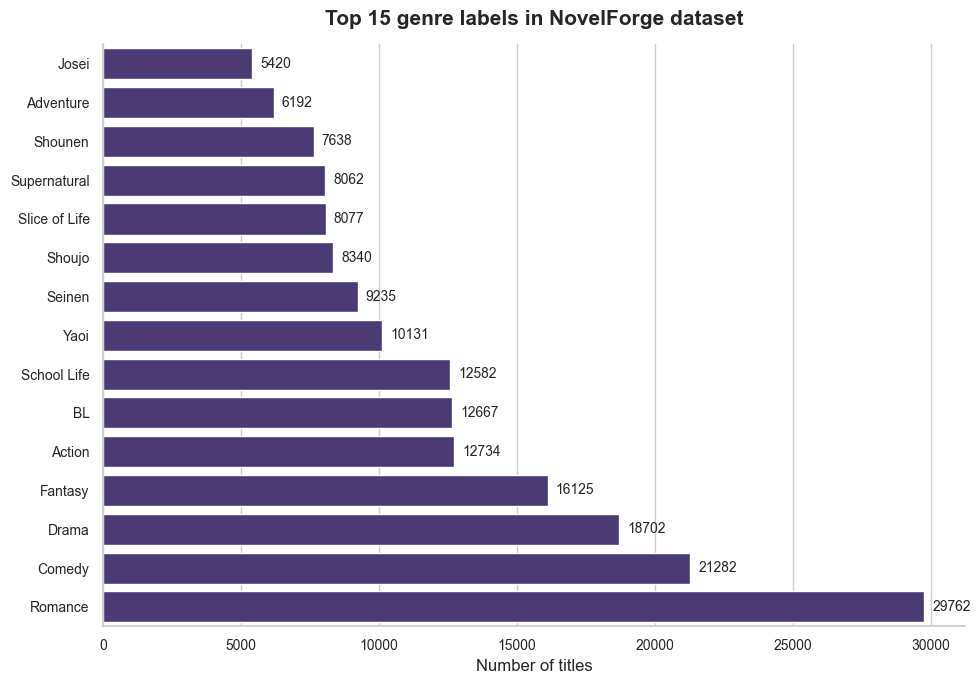

In [8]:
plot_top_genres(
    df_clean,
    genre_column="genre_labels",
    top_n=15,
    title="Top 15 genre labels in NovelForge dataset",
);

**Lecture analytique.** Si un genre domine très nettement le top 15, le dataset est déséquilibré : un modèle naïf pourrait favoriser les classes fréquentes au détriment des genres rares. Pour la suite, il faudra privilégier des métriques adaptées au multi-label comme le F1 macro/micro et analyser les performances par genre.

## 8. Longueur des synopsis

La longueur des textes influence directement les représentations NLP : bag-of-words, TF-IDF, embeddings ou modèles neuronaux.

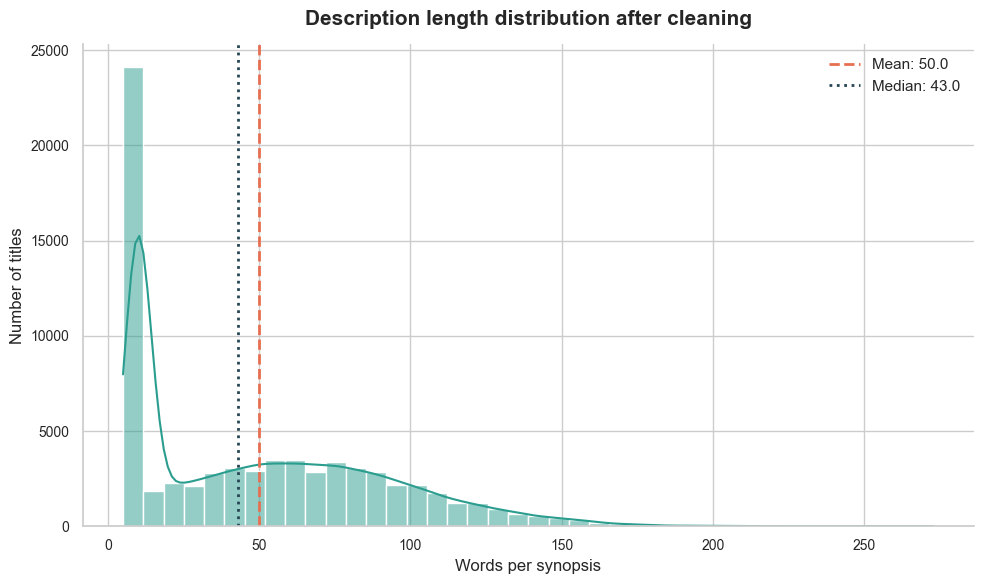

In [9]:
plot_synopsis_length_distribution(
    df_clean,
    length_column="word_count",
    bins=40,
    title="Description length distribution after cleaning",
);

**Lecture analytique.** Une distribution très asymétrique indique que certains synopsis sont beaucoup plus longs que la majorité. Cette information servira à fixer une longueur maximale de séquence ou à contrôler l'impact des textes extrêmes lors de l'entraînement.

## 9. Conclusion EDA

Cette première exploration valide les points clés avant modélisation : qualité du champ synopsis, volume textuel exploitable, anomalies retirées et déséquilibre potentiel des genres. Les prochaines étapes consistent à préparer l'encodage multi-label des genres, définir un split train/validation/test et comparer une baseline TF-IDF à une approche deep learning.